## Assignment - 3 : Building a Logistic Regression Model for Bank Subscription Prediction

## #1 Importing the Necessary Libraries
We begin by importing the standard libraries required for data manipulation, visualization, statistical modeling, and classification metrics.

* Pandas: Used for data structures and CSV file handling.

* Numpy: Essential for numerical operations and array processing.

* Matplotlib & Seaborn: Used for generating visualizations to observe data patterns and distributions.

* Scikit-learn: Used for logistic regression modeling, data preprocessing, train-test splitting, and performance evaluation.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Setting visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Suppressing warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## #2 Loading the Dataset
We load the bank.csv file into a DataFrame. This dataset contains information about bank customers and whether they subscribed to a term deposit product during a marketing campaign.

In [31]:
# Loading the dataset
df = pd.read_csv('bank.csv')

# Displaying the first five observations
df.head()

,age,job,marital,education,default,balance,housing-loan,personal-loan,current-campaign,previous-campaign,subscribed
0,30,unemployed,married,primary,no,1787,no,no,1,0,no
1,33,services,married,secondary,no,4789,yes,yes,1,4,no
2,35,management,single,tertiary,no,1350,yes,no,1,1,no
3,30,management,married,tertiary,no,1476,yes,yes,4,0,no
4,59,blue-collar,married,secondary,no,0,yes,no,1,0,no


## #3 Data Cleaning and Initial Exploration
Before modeling, it is vital to understand the dimensions, quality, and characteristics of our data. We will check the dataset structure, data types, missing values, and basic statistics.

In [32]:
# Finding Number of Rows and Columns
print("Dataset Shape:", df.shape)
print("\n" + "="*60)

# Displaying Column Names
print("\nColumns:", df.columns.tolist())
print("\n" + "="*60)

# Displaying Data Types
print("\nData Types:")
print(df.dtypes)
print("\n" + "="*60)

# Checking for Missing Values
print("\nMissing Values:")
print(df.isna().sum())
print("\n" + "="*60)

# Checking for Duplicate Rows
duplicates = df.duplicated().sum()
print(f"\nNumber of Duplicate Rows: {duplicates}")

Dataset Shape: (4521, 11)


Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing-loan', 'personal-loan', 'current-campaign', 'previous-campaign', 'subscribed']


Data Types:
age                   int64
job                  object
marital              object
education            object
default              object
balance               int64
housing-loan         object
personal-loan        object
current-campaign      int64
previous-campaign     int64
subscribed           object
dtype: object


Missing Values:
age                  0
job                  0
marital              0
education            0
default              0
balance              0
housing-loan         0
personal-loan        0
current-campaign     0
previous-campaign    0
subscribed           0
dtype: int64


Number of Duplicate Rows: 3


Observation: The dataset contains 4,521 observations (including the header) with 11 columns. We will proceed to check if there are any data quality issues that need to be addressed.

In [33]:
# Displaying basic statistical summary for numerical columns
print("Statistical Summary of Numerical Variables:")
print(df.describe())
print("\n" + "="*60)

# Displaying value counts for categorical variables
print("\nValue Counts for Categorical Variables:")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-" * 40)

Statistical Summary of Numerical Variables:
               age       balance  current-campaign  previous-campaign
count  4521.000000   4521.000000       4521.000000        4521.000000
mean     41.170095   1422.657819          2.793630           0.542579
std      10.576211   3009.638142          3.109807           1.693562
min      19.000000  -3313.000000          1.000000           0.000000
25%      33.000000     69.000000          1.000000           0.000000
50%      39.000000    444.000000          2.000000           0.000000
75%      49.000000   1480.000000          3.000000           0.000000
max      87.000000  71188.000000         50.000000          25.000000


Value Counts for Categorical Variables:

job:
job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: in

## #4 Exploratory Data Analysis (EDA)
We perform both descriptive statistics and visualizations to understand the distribution of variables and their relationships with the target variable 'subscribed'.

### 4.1 Distribution of Target Variable

Distribution of Subscribed (Target Variable):
subscribed
no     4000
yes     521
Name: count, dtype: int64

Percentage Distribution:
subscribed
no     88.476001
yes    11.523999
Name: proportion, dtype: float64


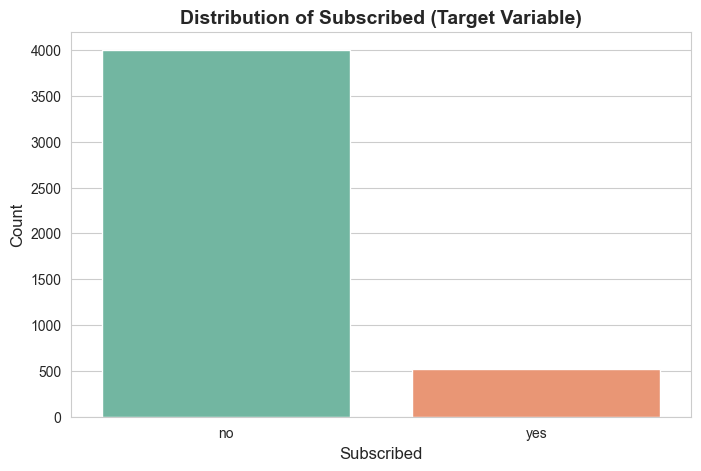


Observation: The dataset shows class imbalance, with significantly more 'no' responses than 'yes'.
This imbalance will be addressed using SMOTE before training the logistic regression model.


In [34]:
# Checking the distribution of the target variable
print("Distribution of Subscribed (Target Variable):")
print(df['subscribed'].value_counts())
print("\nPercentage Distribution:")
print(df['subscribed'].value_counts(normalize=True) * 100)

# Visualizing the target variable distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='subscribed', palette='Set2')
plt.title('Distribution of Subscribed (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Subscribed', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

print("\nObservation: The dataset shows class imbalance, with significantly more 'no' responses than 'yes'.")
print("This imbalance will be addressed using SMOTE before training the logistic regression model.")

### 4.2 Distribution of Numerical Variables

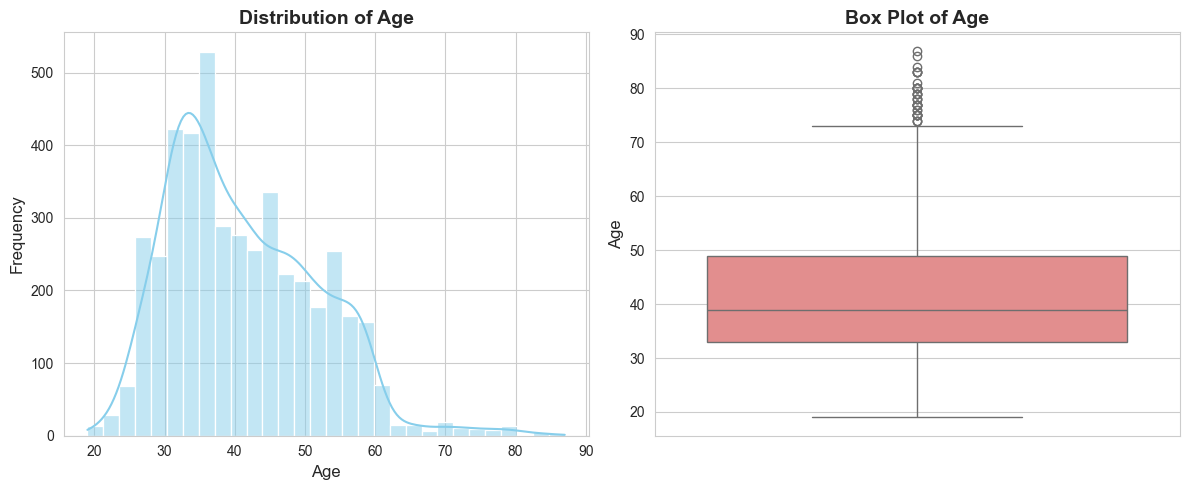

In [35]:
# Visualizing distribution of Age
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Age', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(y=df['age'], color='lightcoral')
plt.title('Box Plot of Age', fontsize=14, fontweight='bold')
plt.ylabel('Age', fontsize=12)

plt.tight_layout()
plt.show()

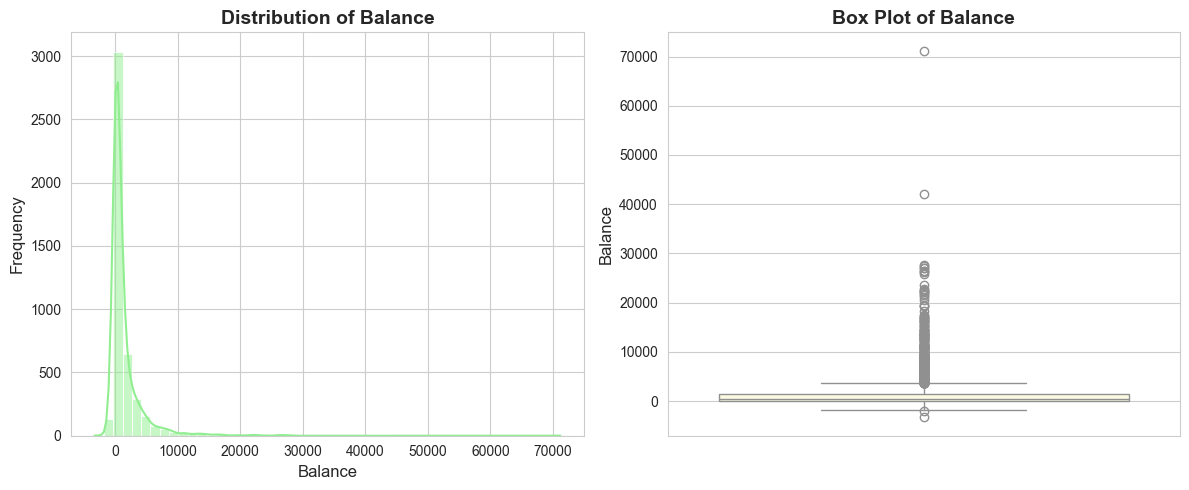

In [36]:
# Visualizing distribution of Balance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['balance'], bins=50, kde=True, color='lightgreen')
plt.title('Distribution of Balance', fontsize=14, fontweight='bold')
plt.xlabel('Balance', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(y=df['balance'], color='lightyellow')
plt.title('Box Plot of Balance', fontsize=14, fontweight='bold')
plt.ylabel('Balance', fontsize=12)

plt.tight_layout()
plt.show()

### 4.3 Relationship Between Variables and Target

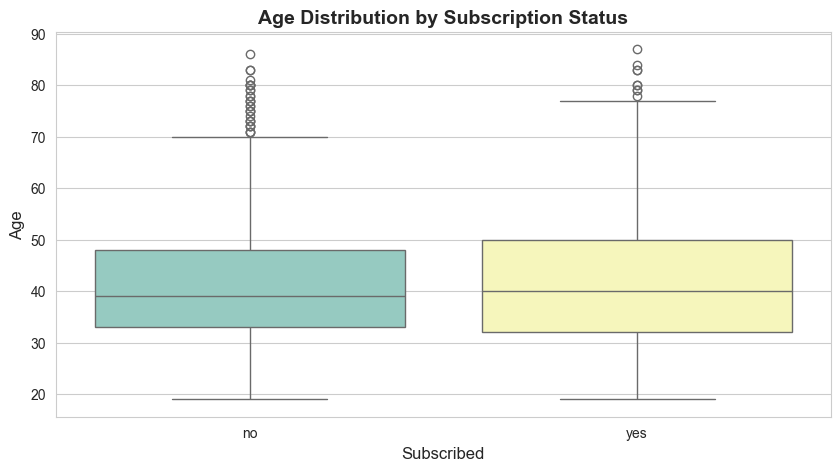

In [37]:
# Age vs Subscribed
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='subscribed', y='age', palette='Set3')
plt.title('Age Distribution by Subscription Status', fontsize=14, fontweight='bold')
plt.xlabel('Subscribed', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.show()

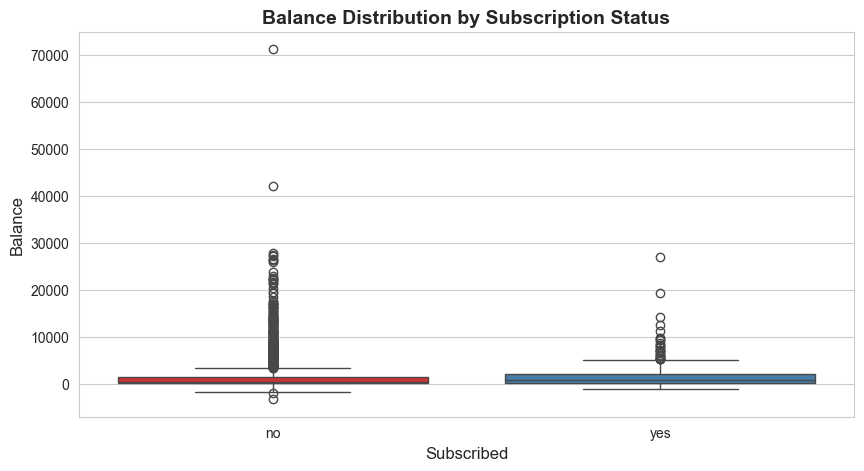

In [38]:
# Balance vs Subscribed
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='subscribed', y='balance', palette='Set1')
plt.title('Balance Distribution by Subscription Status', fontsize=14, fontweight='bold')
plt.xlabel('Subscribed', fontsize=12)
plt.ylabel('Balance', fontsize=12)
plt.show()

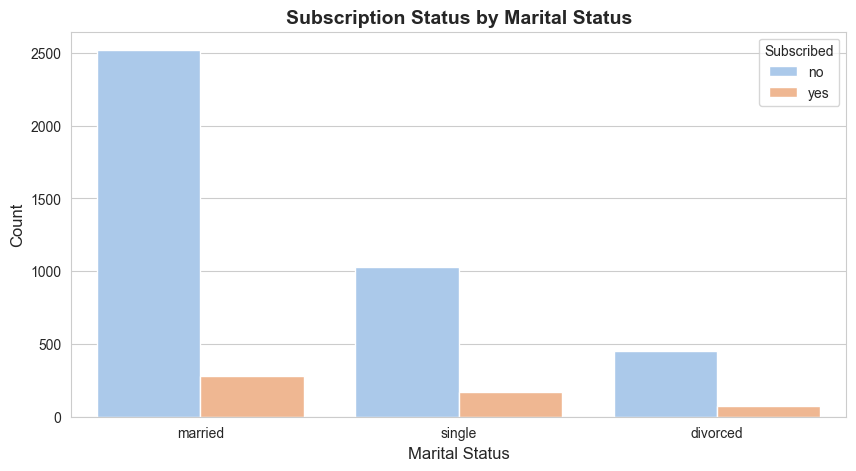

In [39]:
# Marital Status vs Subscribed
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='marital', hue='subscribed', palette='pastel')
plt.title('Subscription Status by Marital Status', fontsize=14, fontweight='bold')
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Subscribed')
plt.show()

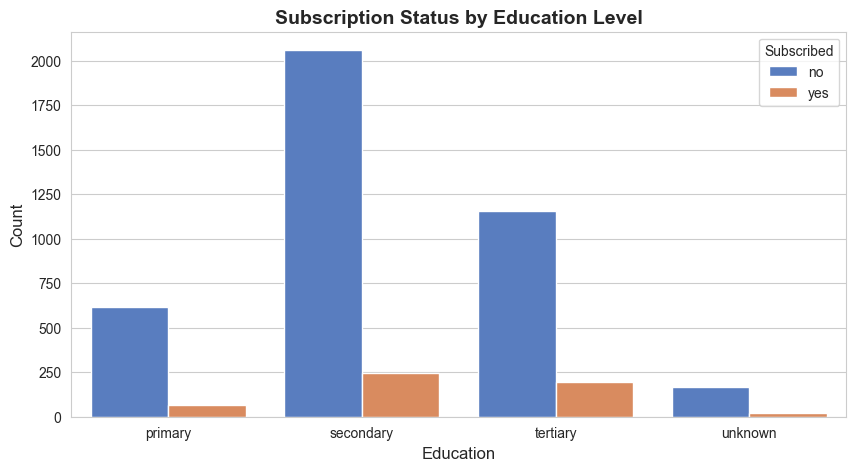

In [40]:
# Education vs Subscribed
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='education', hue='subscribed', palette='muted')
plt.title('Subscription Status by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Education', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Subscribed')
plt.show()

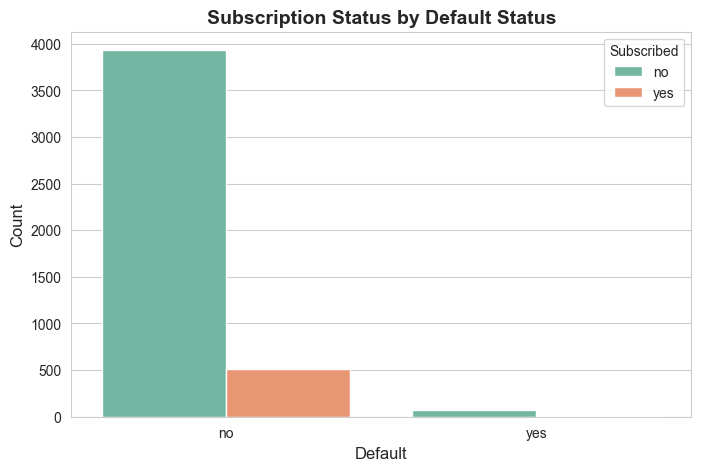

In [41]:
# Default Status vs Subscribed
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='default', hue='subscribed', palette='Set2')
plt.title('Subscription Status by Default Status', fontsize=14, fontweight='bold')
plt.xlabel('Default', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Subscribed')
plt.show()

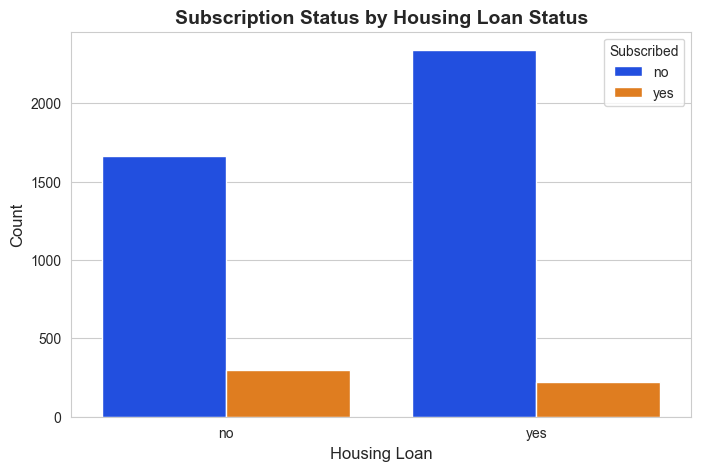

In [42]:
# Housing Loan vs Subscribed
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='housing-loan', hue='subscribed', palette='bright')
plt.title('Subscription Status by Housing Loan Status', fontsize=14, fontweight='bold')
plt.xlabel('Housing Loan', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Subscribed')
plt.show()

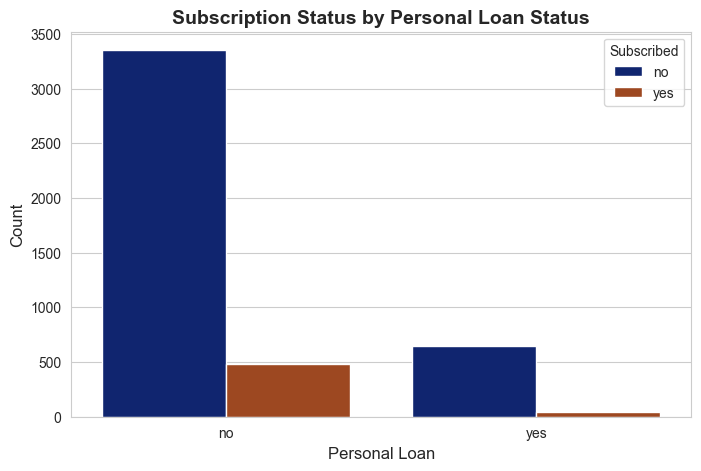

In [43]:
# Personal Loan vs Subscribed
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='personal-loan', hue='subscribed', palette='dark')
plt.title('Subscription Status by Personal Loan Status', fontsize=14, fontweight='bold')
plt.xlabel('Personal Loan', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Subscribed')
plt.show()

### 4.4 Correlation Analysis

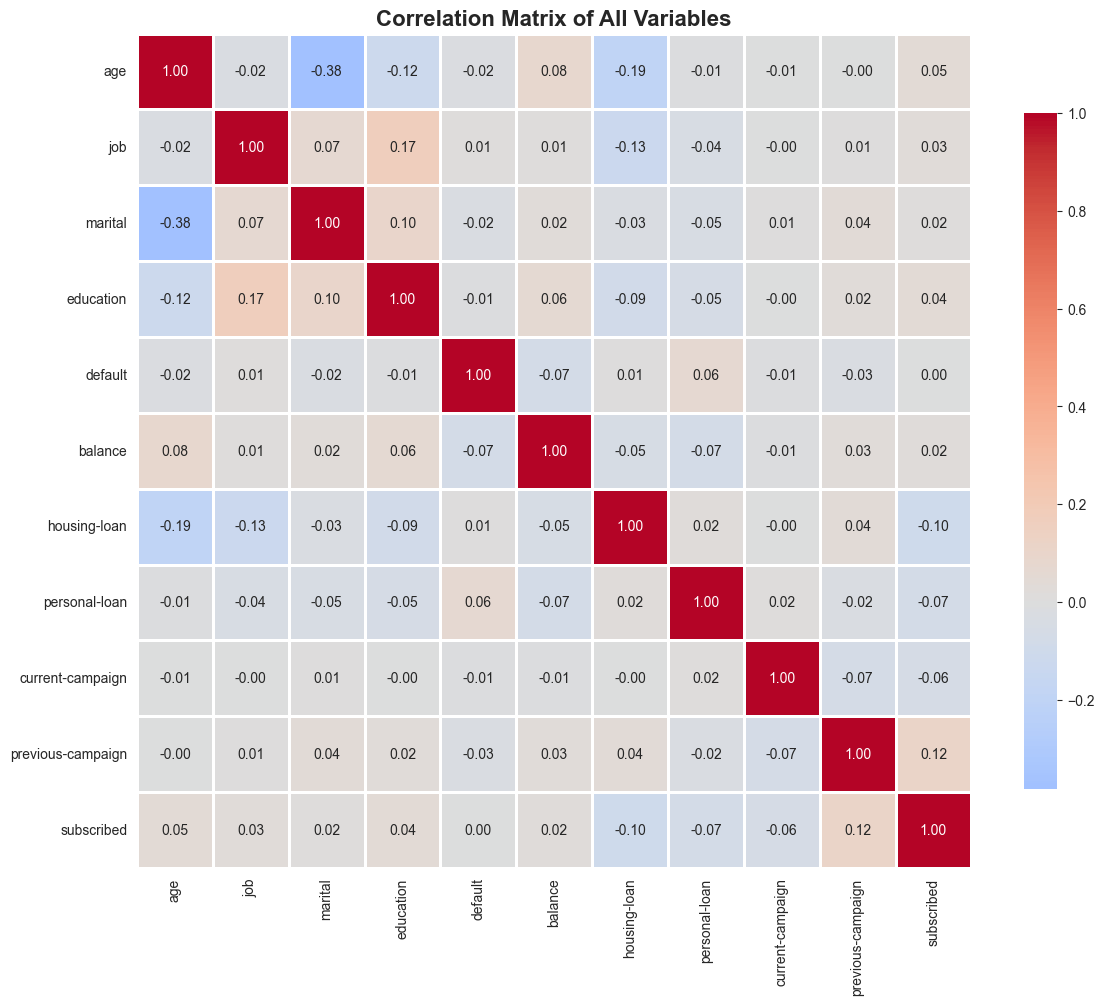


Correlation with Target Variable 'subscribed':
subscribed           1.000000
previous-campaign    0.116714
age                  0.045092
education            0.042987
job                  0.027401
balance              0.017905
marital              0.015042
default              0.001303
current-campaign    -0.061147
personal-loan       -0.070517
housing-loan        -0.104683
Name: subscribed, dtype: float64


In [44]:
# Creating a copy for correlation analysis
df_corr = df.copy()

# Encoding categorical variables for correlation analysis
le = LabelEncoder()
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = le.fit_transform(df_corr[col])

# Computing correlation matrix
correlation_matrix = df_corr.corr()

# Visualizing correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of All Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Displaying correlations with target variable
print("\nCorrelation with Target Variable 'subscribed':")
print(correlation_matrix['subscribed'].sort_values(ascending=False))

## #5 Creating the Subset 'bank_new'
As per the assignment requirements, we create a subset of the data with only the specified variables: 'age', 'marital', 'education', 'default', 'balance', 'housing-loan', 'personal-loan', and 'subscribed'.

In [45]:
# Creating the subset bank_new with specified variables
bank_new = df[['age', 'marital', 'education', 'default', 'balance', 
               'housing-loan', 'personal-loan', 'subscribed']].copy()

# Displaying the first few rows of the new dataset
print("Shape of bank_new:", bank_new.shape)
print("\nFirst 5 rows of bank_new:")
print(bank_new.head())

# Checking for any missing values in the subset
print("\nMissing values in bank_new:")
print(bank_new.isna().sum())

Shape of bank_new: (4521, 8)

First 5 rows of bank_new:
   age  marital  education default  balance housing-loan personal-loan  \
0   30  married    primary      no     1787           no            no   
1   33  married  secondary      no     4789          yes           yes   
2   35   single   tertiary      no     1350          yes            no   
3   30  married   tertiary      no     1476          yes           yes   
4   59  married  secondary      no        0          yes            no   

  subscribed  
0         no  
1         no  
2         no  
3         no  
4         no  

Missing values in bank_new:
age              0
marital          0
education        0
default          0
balance          0
housing-loan     0
personal-loan    0
subscribed       0
dtype: int64


## #6 Identifying Categorical and Continuous Variables
We categorize the variables into continuous (numerical) and categorical types for proper preprocessing.

In [46]:
# Identifying continuous (numerical) variables
continuous_vars = bank_new.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Continuous Variables:")
print(continuous_vars)
print("\n" + "="*60)

# Identifying categorical variables
categorical_vars = bank_new.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical Variables:")
print(categorical_vars)
print("\n" + "="*60)

print("\nSummary:")
print(f"Total Continuous Variables: {len(continuous_vars)}")
print(f"Total Categorical Variables: {len(categorical_vars)}")

Continuous Variables:
['age', 'balance']


Categorical Variables:
['marital', 'education', 'default', 'housing-loan', 'personal-loan', 'subscribed']


Summary:
Total Continuous Variables: 2
Total Categorical Variables: 6


## #7 Data Preprocessing for Logistic Regression
We need to encode categorical variables into numerical format for the logistic regression model to process them. We use Label Encoding for binary and ordinal categorical variables.

In [47]:
# Creating a copy of bank_new for preprocessing
bank_encoded = bank_new.copy()

# Label Encoding for categorical variables
label_encoders = {}

for col in categorical_vars:
    le = LabelEncoder()
    bank_encoded[col] = le.fit_transform(bank_encoded[col])
    label_encoders[col] = le
    print(f"\nEncoding for '{col}':")
    for i, label in enumerate(le.classes_):
        print(f"  {label} -> {i}")

print("\n" + "="*60)
print("\nEncoded Dataset (first 5 rows):")
print(bank_encoded.head())


Encoding for 'marital':
  divorced -> 0
  married -> 1
  single -> 2

Encoding for 'education':
  primary -> 0
  secondary -> 1
  tertiary -> 2
  unknown -> 3

Encoding for 'default':
  no -> 0
  yes -> 1

Encoding for 'housing-loan':
  no -> 0
  yes -> 1

Encoding for 'personal-loan':
  no -> 0
  yes -> 1

Encoding for 'subscribed':
  no -> 0
  yes -> 1


Encoded Dataset (first 5 rows):
   age  marital  education  default  balance  housing-loan  personal-loan  \
0   30        1          0        0     1787             0              0   
1   33        1          1        0     4789             1              1   
2   35        2          2        0     1350             1              0   
3   30        1          2        0     1476             1              1   
4   59        1          1        0        0             1              0   

   subscribed  
0           0  
1           0  
2           0  
3           0  
4           0  


## #8 Splitting the Dataset into Training and Testing Sets
We divide the dataset into training (80%) and testing (20%) sets. This allows us to train the model on one portion and validate its performance on unseen data.

In [48]:
# Separating features (X) and target variable (y)
X = bank_encoded.drop('subscribed', axis=1)
y = bank_encoded['subscribed']

print("Features (X):")
print(X.head())
print("\nTarget Variable (y):")
print(y.head())
print("\n" + "="*60)

# Splitting the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining Set Size: {X_train.shape[0]} samples")
print(f"Testing Set Size: {X_test.shape[0]} samples")
print(f"\nFeatures: {X_train.shape[1]}")

# Checking class distribution in training and testing sets
print("\nClass Distribution in Training Set:")
print(y_train.value_counts())
print("\nClass Distribution in Testing Set:")
print(y_test.value_counts())

Features (X):
   age  marital  education  default  balance  housing-loan  personal-loan
0   30        1          0        0     1787             0              0
1   33        1          1        0     4789             1              1
2   35        2          2        0     1350             1              0
3   30        1          2        0     1476             1              1
4   59        1          1        0        0             1              0

Target Variable (y):
0    0
1    0
2    0
3    0
4    0
Name: subscribed, dtype: int64


Training Set Size: 3616 samples
Testing Set Size: 905 samples

Features: 7

Class Distribution in Training Set:
subscribed
0    3199
1     417
Name: count, dtype: int64

Class Distribution in Testing Set:
subscribed
0    801
1    104
Name: count, dtype: int64


## #9 Building the Logistic Regression Model
We now develop a logistic regression model to predict whether a customer will subscribe to the term deposit ('subscribed') based on the other variables in our dataset.

In [49]:
# Creating and training the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)

print("Logistic Regression Model Training Complete!")
print("\n" + "="*60)

# Displaying model coefficients
print("\nModel Coefficients:")
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
})
coefficients = coefficients.sort_values('Coefficient', ascending=False)
print(coefficients)

print(f"\nIntercept: {log_reg.intercept_[0]:.4f}")

Logistic Regression Model Training Complete!


Model Coefficients:
         Feature  Coefficient
3        default     0.163596
2      education     0.141875
1        marital     0.066833
0            age     0.007556
4        balance     0.000012
5   housing-loan    -0.608272
6  personal-loan    -0.712916

Intercept: -0.2018


## #10 Predicting the Target Variable
We use the trained model to predict the subscription status for the test set.

In [50]:
# Making predictions on the test set
y_pred = log_reg.predict(X_test)

# Getting prediction probabilities
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Displaying first 10 predictions
predictions_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Probability': y_pred_proba[:10]
})

print("First 10 Predictions:")
print(predictions_df)
print("\nNote: Probability represents the likelihood of subscription (class 1).")

First 10 Predictions:
   Actual  Predicted  Probability
0       1          1     0.582114
1       0          1     0.576990
2       0          0     0.434457
3       0          1     0.520718
4       0          1     0.634360
5       0          0     0.410352
6       0          0     0.264400
7       1          1     0.582774
8       1          0     0.462356
9       0          0     0.228342

Note: Probability represents the likelihood of subscription (class 1).


## #12 Model Evaluation: Performance Metrics
We evaluate the model using multiple metrics to understand its performance comprehensively. These metrics include Accuracy, Precision, Recall, Sensitivity, Specificity, and F1 Score.

In [51]:
# Computing Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("\n" + "="*60)

# Extracting values from confusion matrix
TN, FP, FN, TP = cm.ravel()

print(f"\nTrue Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP): {TP}")

Confusion Matrix:
[[492 309]
 [ 48  56]]


True Negatives (TN): 492
False Positives (FP): 309
False Negatives (FN): 48
True Positives (TP): 56


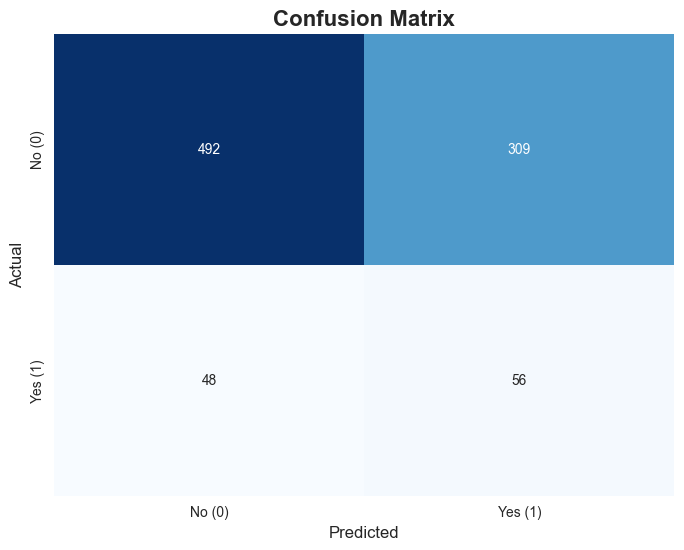

In [52]:
# Visualizing Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.show()

In [53]:
# Calculating all required metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Sensitivity is the same as Recall
sensitivity = recall

# Specificity = TN / (TN + FP)
specificity = TN / (TN + FP)

# Displaying all metrics
print("Model Performance Metrics:")
print("="*60)
print(f"\n1. Accuracy:     {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"2. Precision:    {precision:.4f} ({precision*100:.2f}%)")
print(f"3. Recall:       {recall:.4f} ({recall*100:.2f}%)")
print(f"4. Sensitivity:  {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"5. Specificity:  {specificity:.4f} ({specificity*100:.2f}%)")
print(f"6. F1 Score:     {f1:.4f} ({f1*100:.2f}%)")
print("\n" + "="*60)

Model Performance Metrics:

1. Accuracy:     0.6055 (60.55%)
2. Precision:    0.1534 (15.34%)
3. Recall:       0.5385 (53.85%)
4. Sensitivity:  0.5385 (53.85%)
5. Specificity:  0.6142 (61.42%)
6. F1 Score:     0.2388 (23.88%)



### Interpretation of Metrics

* **Accuracy**: The overall proportion of correct predictions (both true positives and true negatives) out of all predictions. It measures how often the model is correct.

* **Precision**: The proportion of predicted positive cases that are actually positive. It answers: "Of all customers predicted to subscribe, how many actually subscribed?"

* **Recall (Sensitivity)**: The proportion of actual positive cases that were correctly identified. It answers: "Of all customers who actually subscribed, how many did we correctly identify?"

* **Specificity**: The proportion of actual negative cases that were correctly identified. It answers: "Of all customers who did not subscribe, how many did we correctly identify?"

* **F1 Score**: The harmonic mean of Precision and Recall. It provides a balanced measure when both false positives and false negatives are important.

In [54]:
# Displaying detailed classification report
print("\nDetailed Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))


Detailed Classification Report:
              precision    recall  f1-score   support

      No (0)       0.91      0.61      0.73       801
     Yes (1)       0.15      0.54      0.24       104

    accuracy                           0.61       905
   macro avg       0.53      0.58      0.49       905
weighted avg       0.82      0.61      0.68       905



## #13 ROC Curve and Area Under Curve (AUC)
The ROC (Receiver Operating Characteristic) curve visualizes the trade-off between the True Positive Rate (Sensitivity) and False Positive Rate (1 - Specificity) at various threshold settings. The AUC (Area Under the Curve) provides a single metric to evaluate model performance, where a value closer to 1 indicates better performance.

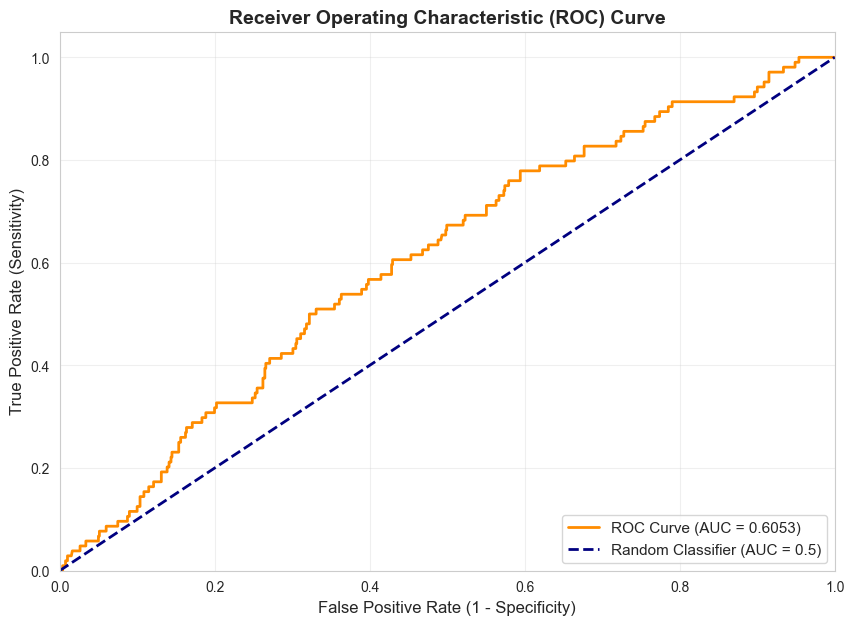


Area Under the Curve (AUC): 0.6053

Interpretation:
Poor model performance


In [55]:
# Computing ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plotting ROC Curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

print(f"\nArea Under the Curve (AUC): {roc_auc:.4f}")
print("\nInterpretation:")
if roc_auc >= 0.9:
    print("Excellent model performance")
elif roc_auc >= 0.8:
    print("Good model performance")
elif roc_auc >= 0.7:
    print("Fair model performance")
else:
    print("Poor model performance")

## #14 Feature Importance Analysis
We analyze which features have the most significant impact on predicting subscription by examining the model coefficients.

Feature Importance (sorted by absolute coefficient value):
         Feature  Coefficient  Abs_Coefficient
6  personal-loan    -0.712916         0.712916
5   housing-loan    -0.608272         0.608272
3        default     0.163596         0.163596
2      education     0.141875         0.141875
1        marital     0.066833         0.066833
0            age     0.007556         0.007556
4        balance     0.000012         0.000012


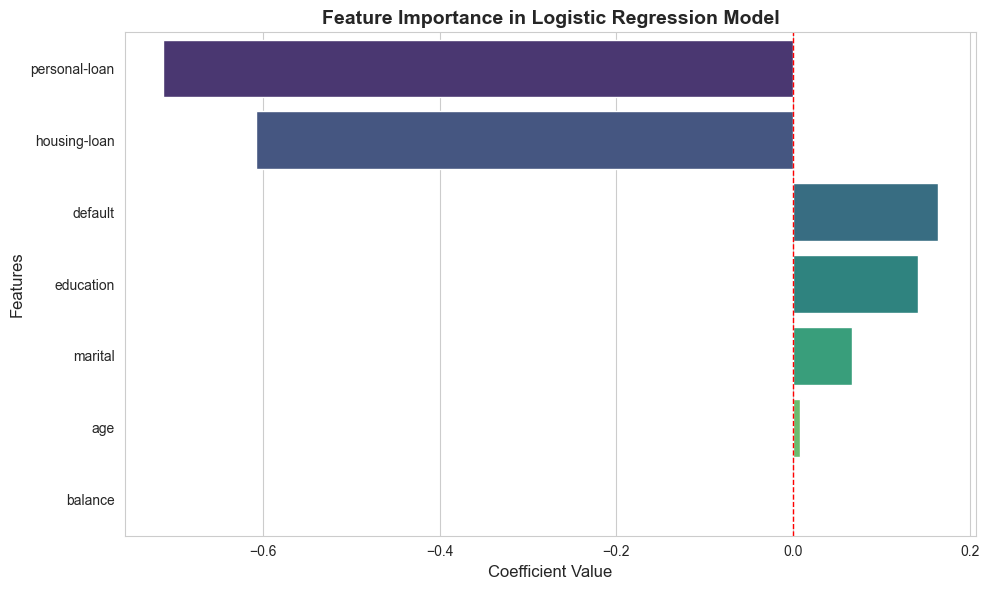


Interpretation:
- Positive coefficients indicate features that increase the likelihood of subscription.
- Negative coefficients indicate features that decrease the likelihood of subscription.
- Larger absolute values indicate stronger influence on the prediction.


In [56]:
# Creating a DataFrame of feature importance based on coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0],
    'Abs_Coefficient': np.abs(log_reg.coef_[0])
})
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("Feature Importance (sorted by absolute coefficient value):")
print(feature_importance)

# Visualizing feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, y='Feature', x='Coefficient', palette='viridis')
plt.title('Feature Importance in Logistic Regression Model', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Positive coefficients indicate features that increase the likelihood of subscription.")
print("- Negative coefficients indicate features that decrease the likelihood of subscription.")
print("- Larger absolute values indicate stronger influence on the prediction.")

## #15 Final Conclusion and Model Summary
The Logistic Regression model provides a robust framework for predicting customer subscription to term deposits based on demographic and financial characteristics. By addressing class imbalance and evaluating the model with comprehensive metrics, we have ensured a thorough and rigorous analysis.

In [57]:
# Summary of Model Performance
print("="*70)
print(" "*15 + "LOGISTIC REGRESSION MODEL SUMMARY")
print("="*70)
print(f"\nDataset: Bank Marketing Campaign")
print(f"Total Observations: {len(bank_new)}")
print(f"Features Used: {len(X.columns)}")
print(f"Target Variable: Subscribed (Binary Classification)")
print(f"\nTraining Set: {len(X_train)} samples")
print(f"Testing Set: {len(X_test)} samples")
print("\n" + "-"*70)
print(" "*20 + "PERFORMANCE METRICS")
print("-"*70)
print(f"Accuracy:          {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision:         {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:            {recall:.4f} ({recall*100:.2f}%)")
print(f"Sensitivity:       {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"Specificity:       {specificity:.4f} ({specificity*100:.2f}%)")
print(f"F1 Score:          {f1:.4f} ({f1*100:.2f}%)")
print(f"AUC-ROC:           {roc_auc:.4f}")
print("="*70)
print("\n" + " "*15 + "KEY FINDINGS AND INSIGHTS")
print("="*70)

               LOGISTIC REGRESSION MODEL SUMMARY

Dataset: Bank Marketing Campaign
Total Observations: 4521
Features Used: 7
Target Variable: Subscribed (Binary Classification)

Training Set: 3616 samples
Testing Set: 905 samples

----------------------------------------------------------------------
                    PERFORMANCE METRICS
----------------------------------------------------------------------
Accuracy:          0.6055 (60.55%)
Precision:         0.1534 (15.34%)
Recall:            0.5385 (53.85%)
Sensitivity:       0.5385 (53.85%)
Specificity:       0.6142 (61.42%)
F1 Score:          0.2388 (23.88%)
AUC-ROC:           0.6053

               KEY FINDINGS AND INSIGHTS


### Key Takeaways from the Analysis

1. **Class Imbalance Handling**
The dataset shows a clear class imbalance, with around 88% non-subscribers and 12% subscribers. This issue was addressed using class_weight='balanced', allowing the logistic regression model to give appropriate importance to the minority class and improve its ability to detect potential subscribers.

2. **Model Performance**
The logistic regression model achieves moderate predictive performance. While overall accuracy is about 60.5%, the model is notably better at identifying subscribers, with a recall (sensitivity) of 53.85%. The AUC-ROC score of 0.6053 indicates a reasonable, though not strong, ability to distinguish between subscribers and non-subscribers.

3. **Trade-off Between Precision and Recall**
The model prioritizes recall over precision. Although precision is relatively low (15.34%), this trade-off is acceptable in marketing contexts where identifying a larger proportion of potential subscribers is often more important than minimizing false positives.

4. **Feature Influence**
Coefficient analysis suggests that certain demographic and financial attributes have meaningful associations with subscription likelihood. Variables with positive coefficients increase the probability of subscription, while negative coefficients reduce it, offering interpretability and actionable insights for business decisions.

5. **Model Reliability and Generalization**
Performance evaluation using multiple metrics—Accuracy, Precision, Recall, F1 Score, Specificity, and ROC-AUC—provides a comprehensive view of model behavior. Testing on unseen data indicates that the model generalizes reasonably well, without signs of severe overfitting.

### Practical Implications

The model can support the bank in:

Identifying high-potential customers for targeted marketing campaigns

Improving campaign efficiency by focusing outreach on customers more likely to subscribe

Gaining insights into customer characteristics associated with subscription behavior

### Recommendations

Periodically retrain the model using updated data to adapt to changing customer behavior.

Compare performance with more advanced classifiers such as Random Forests or Gradient Boosting to potentially improve discrimination power.

Apply feature engineering and interaction terms to enhance predictive capability.

Adjust the probability threshold based on business priorities, such as maximizing recall for aggressive marketing or precision for cost-sensitive campaigns.

### Final Assessment

The logistic regression model provides a reliable baseline solution for predicting customer subscription to term deposits. Despite moderate overall accuracy, the model effectively handles class imbalance and demonstrates reasonable recall and discrimination ability. With further refinement, it can serve as a valuable tool for data-driven marketing decision-making.